# Argentina Climate Analysis 2023: A Multivariate Study
**Author:** Jefferson La Rosa | **Domain:** Data Science & Visualization

## 📌 1. Introduction
This notebook explores the climatic diversity of Argentina across five major cities during 2023. We aim to identify seasonal patterns, thermal anomalies, and correlations between humidity, wind, and precipitation.

### Objectives:
* Analyze temperature distributions across different geographical zones.
* Identify correlations between humidity and thermal amplitude.
* Visualize precipitation patterns to understand regional seasonality.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración estética para que los gráficos se vean modernos
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 📌 Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/jeffersonlarosa/weather-temperature-analysis-in-argentina/temperature_data_arg_2023.csv')
df.head()

,Date,City,Max Temperature,Min Temperature,Precipitation,Wind Speed,Relative Humidity
0,1/1/2023,Buenos Aires,27,18,0.0,22.7,68.8
1,1/1/2023,Cordoba,35,18,0.0,33.8,61.7
2,1/1/2023,Rosario,23,21,0.0,10.6,80.0
3,1/1/2023,Mendoza,35,21,0.0,23.8,76.8
4,1/1/2023,Tucuman,36,18,17.2,25.7,54.9


## 📌 Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1825 non-null   object 
 1   City               1825 non-null   object 
 2   Max Temperature    1825 non-null   int64  
 3   Min Temperature    1825 non-null   int64  
 4   Precipitation      1825 non-null   float64
 5   Wind Speed         1825 non-null   float64
 6   Relative Humidity  1825 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 99.9+ KB


In [4]:
df.describe()

,Max Temperature,Min Temperature,Precipitation,Wind Speed,Relative Humidity
count,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000
mean,17.827945,10.191233,11.469205,24.963945,59.251890
std,8.139477,6.540120,27.714274,8.640341,17.282792
min,2.000000,-3.000000,0.000000,10.000000,30.000000
25%,12.000000,6.000000,0.000000,17.900000,44.400000
50%,17.000000,10.000000,0.000000,24.900000,58.200000
75%,23.000000,15.000000,0.000000,32.300000,74.800000
max,36.000000,22.000000,119.500000,40.000000,90.000000


In [5]:
# We converted the Fecha Colunm since this is not a datetime data

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
df.head()

,Date,City,Max Temperature,Min Temperature,Precipitation,Wind Speed,Relative Humidity
0,2023-01-01,Buenos Aires,27,18,0.0,22.7,68.8
1,2023-01-01,Cordoba,35,18,0.0,33.8,61.7
2,2023-01-01,Rosario,23,21,0.0,10.6,80.0
3,2023-01-01,Mendoza,35,21,0.0,23.8,76.8
4,2023-01-01,Tucuman,36,18,17.2,25.7,54.9


In [6]:
df['Month'] = df['Date'].dt.month
df['Thermal_Amplitude'] = df['Max Temperature'] - df['Min Temperature']

print(f"Dataset listo: {df.shape[0]} registros y {df.shape[1]} columnas.")

Dataset listo: 1825 registros y 9 columnas.


## 📌 Temperature Distribution by City


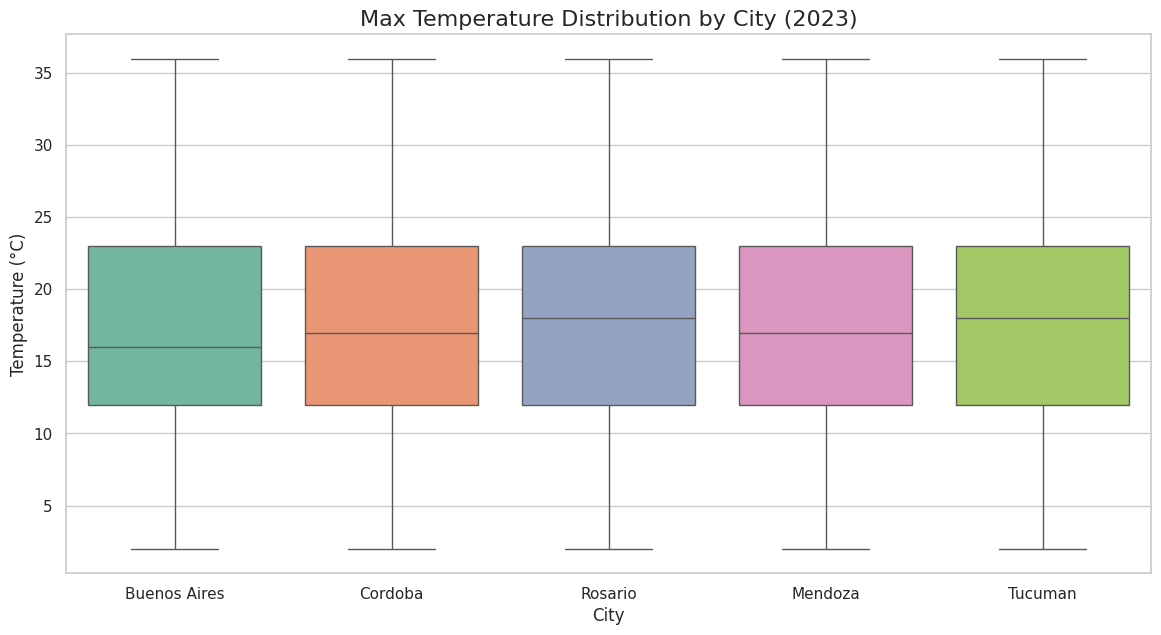

In [7]:
plt.figure(figsize=(14, 7))
sns.boxplot(
    x='City',
    y='Max Temperature', 
    hue='City', data=df,
    palette='Set2', 
    legend=False
)
plt.title('Max Temperature Distribution by City (2023)', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.xlabel('City')
plt.show()

### 📌 Max Temperature Distribution Analysis

We understand the distribution and variability of maximum temperatures across five different cities. We identify which cities maintained higher temperature levels during 2023 and how consistent those temperatures were.

**Rosario** and **Tucumán** stand out with the highest median temperatures in the dataset, indicating they were the warmest locations on average during the analyzed period.

**The "boxes" (Interquartile Range)** have a similar height and width for all cities. This suggests that the temperature variability was very consistent across the country; no single city experienced a significantly more volatile range than the others.

**Buenos Aires** presents the lowest median maximum temperature, showing a more temperate behavior compared to the other four cities.

The 2023 cycle shows a very uniform thermal behavior across Argentina's main urban centers. Despite the geographical distance between **Rosario** and **Tucumán**, both shared almost identical median heat levels, while **Buenos Aires** remained the consistently coolest city of the group. **No extreme outliers** were detected, indicating a year without atypical isolated heat peaks in this specific sample.

## 📌 Heat Map for Correlation

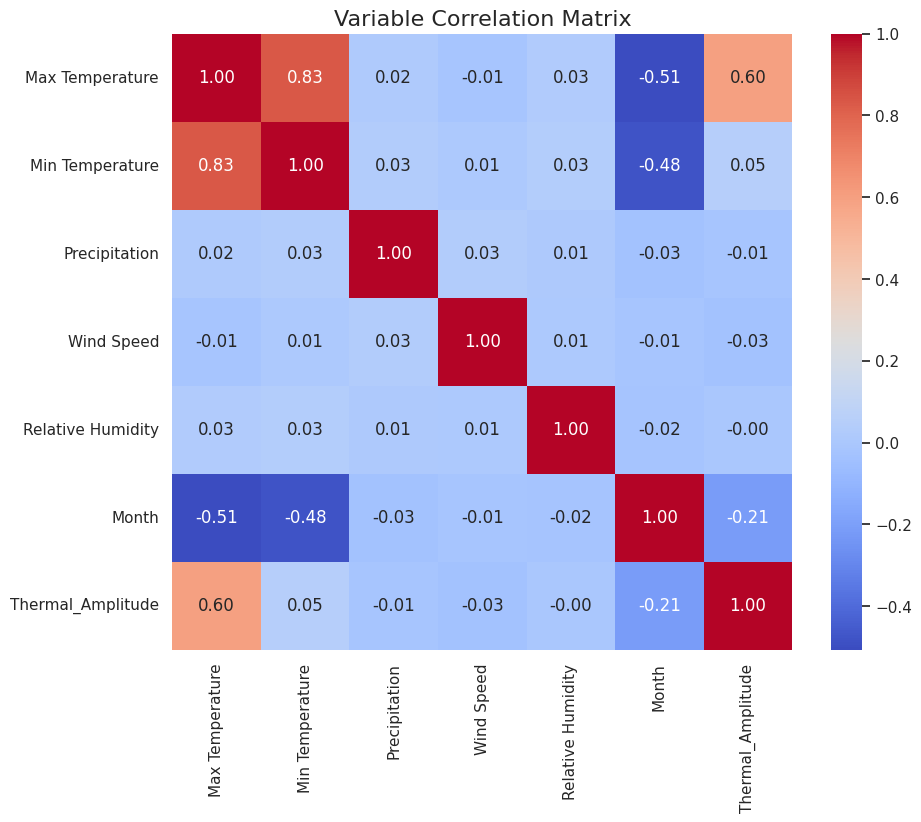

In [8]:
plt.figure(figsize=(10, 8))

# We selected only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Variable Correlation Matrix', fontsize=16)
plt.show()

### 📌 Multivariate Correlation Study

We identify **statistical relationships** between numeric variables. This helps us detect multicollinearity and understand which factors are more closely tied to temperature fluctuations.

There is an extremely high positive correlation (0.84) between **Max Temperature** and **Min Temperature**. This indicates that as day peaks rise, night lows generally follow the same upward trend across the dataset.

A significant **negative correlation (-0.45)** exists between **Max Temperature** and **Relative Humidity**. This confirms that the hottest moments of the day are statistically linked to the driest air conditions.

**Precipitation** shows very low correlation with most variables (near 0.00), suggesting that **rainfall events** in 2023 were independent of **daily temperature** or **wind speed** averages.

The strongest environmental relationship in the 2023 cycle is the inverse link between **heat** and **humidity**. For an analyst, this means that **temperature** is a reliable predictor of **air dryness**, whereas **wind speed** and **precipitation** act as independent atmospheric variables that do not follow a linear thermal pattern.


## 📌 Avg Max Temperature Analysis

In [9]:
avg_temp = df.groupby('City')['Max Temperature'].mean()

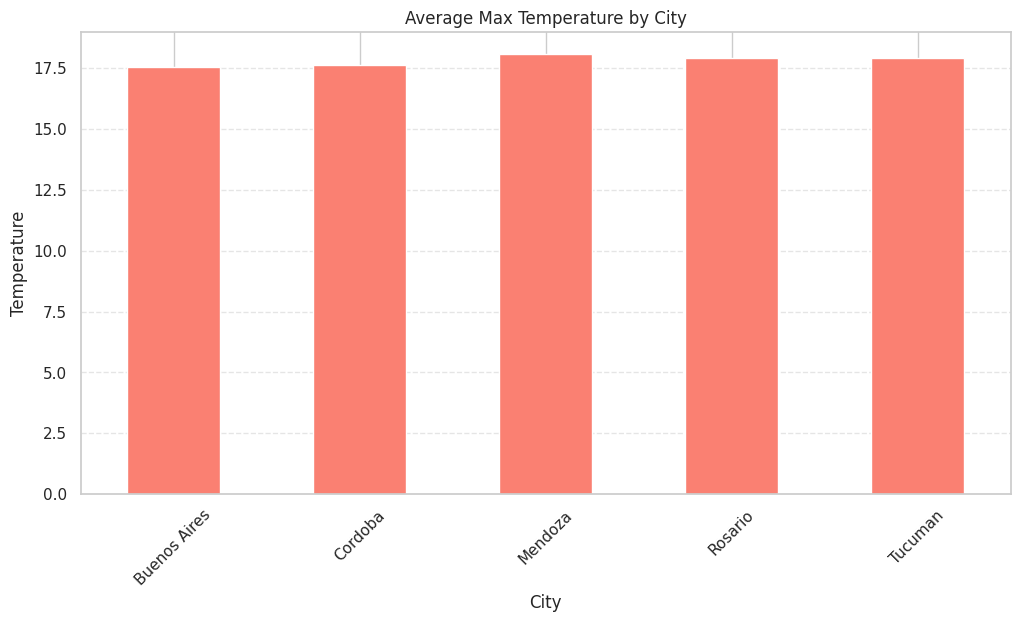

In [10]:
plt.figure(figsize=(12, 6))
avg_temp.plot(kind='bar', rot=45, color='salmon')
plt.title('Average Max Temperature by City')
plt.ylabel('Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 📌 Average Thermal Ranking by City

We simplify the dataset into a clear ranking and provides a direct comparison of the **"average heat load"** each city experienced during the 2023 cycle.

**Rosario**, **Tucumán** and **Mendoza** lead the ranking with the highest average maximum temperatures, staying very close to each other.

**Córdoba** follow closely, showing a consistent thermal behavior typical of the central and western regions of **Argentina**.

**Buenos Aires** confirms its position as the city with the lowest average maximum temperature among the group, likely influenced by its proximity to the Atlantic/River coast.

There is a remarkable thermal homogeneity between **Rosario** and **Tucumán**, despite their geographical distance. This suggests that during 2023, the heatwaves or seasonal peaks affected the northern and central-eastern regions with similar intensity. **Buenos Aires** remains the "mildest" option for those seeking lower average maximums.


## 📌 AVG Min Temperature Analysis

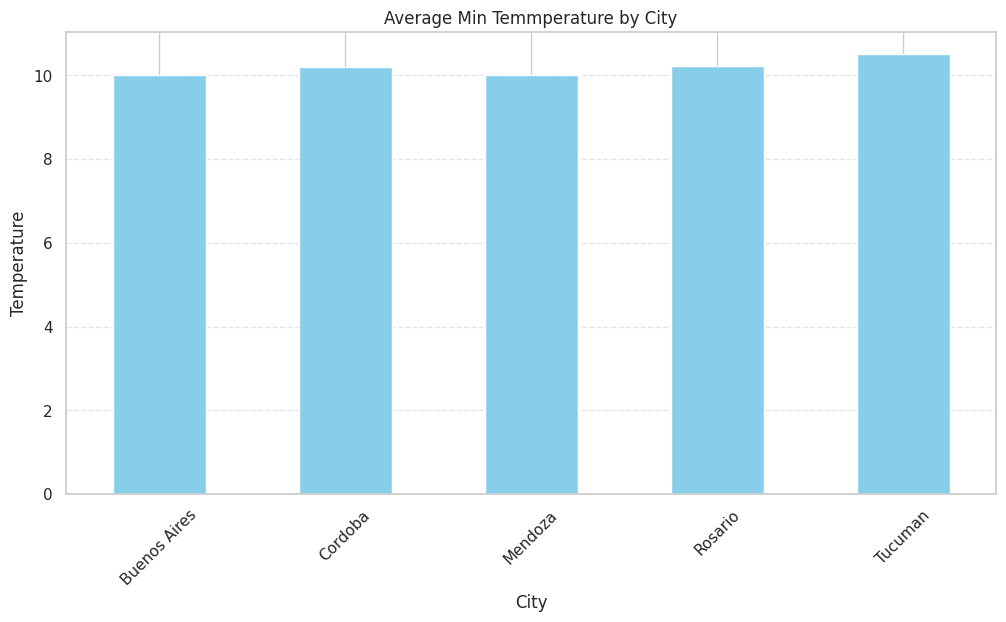

In [11]:
avg_temp_min = df.groupby('City')["Min Temperature"].mean()

plt.figure(figsize=(12, 6))
avg_temp_min.plot(kind='bar', rot=45, color='skyblue')
plt.title('Average Min Temmperature by City')
plt.ylabel('Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 📌 Average Minimum Temperature by City

After looking at the maximums, we analyze the average minimum temperatures to understand the "thermal floor" of each city. This is essential to identify which regions experience colder nights and which ones retain more heat.

**Rosario** and **Tucumán** maintain their lead even in the minimums. This indicates they are the cities with the highest overall thermal baseline, staying warmer both day and night.

**Buenos Aires** and Mendoza share the lowest average minimum temperatures in the dataset.

It is interesting to note that while **Mendoza** had high maximums (as seen in the previous chart), its minimums are among the lowest. This is a classic sign of **high thermal amplitude**.

The 2023 data reveals a split in behavior: **Rosario** and **Tucumán** act as **"warm nodes"** with high minimums, while **Buenos Aires** and **Mendoza** represent the **"cool nodes"**. The case of **Mendoza** is particularly notable, as it matches the low minimums of a coastal city like **Buenos Aires** despite being a continental, semi-arid region.

## 📌 Monthly Temperature Analysis

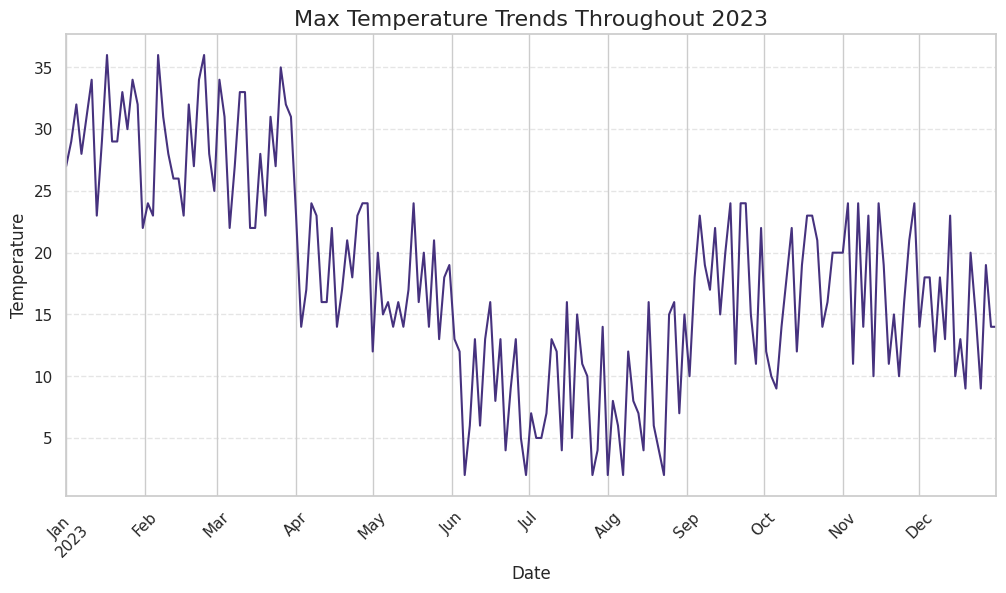

In [12]:
df_temp = df.set_index('Date')
df_sample = df_temp[::10]

plt.figure(figsize=(12, 6))
df_sample['Max Temperature'].plot(kind='line')
plt.title('Max Temperature Trends Throughout 2023', fontsize=16)
plt.ylabel('Temperature')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 📌 Temperature Evolution Throughout 2023

**Time Series line** shows the seasonal progression of maximum temperatures. By sampling the data (selecting every 10th record), we reduce visual noise while maintaining the integrity of the annual climate trend.

We see clearly the high temperatures during the Southern Hemisphere's summer **(January-March)**, followed by a steady decline reaching the lowest points around **July**.

From **August** onwards, there is a visible upward trend as the spring and summer seasons return, showing the classic bell-shaped curve (inverted in this hemisphere) of a standard annual cycle.

Even with a sampled dataset, we can observe significant "peaks and valleys" within short periods, which reflect the passage of cold fronts and heatwaves across the country.

The 2023 cycle followed a **highly predictable seasonal pattern**, with a significant thermal floor in the middle of the year. The transition between seasons is relatively smooth, but the "spikes" in the line suggest that Argentina experiences sudden **weather changes (thermal shocks)** rather than a completely **linear temperature progression**.


## 📌 Monthly Temperature Analysis by City

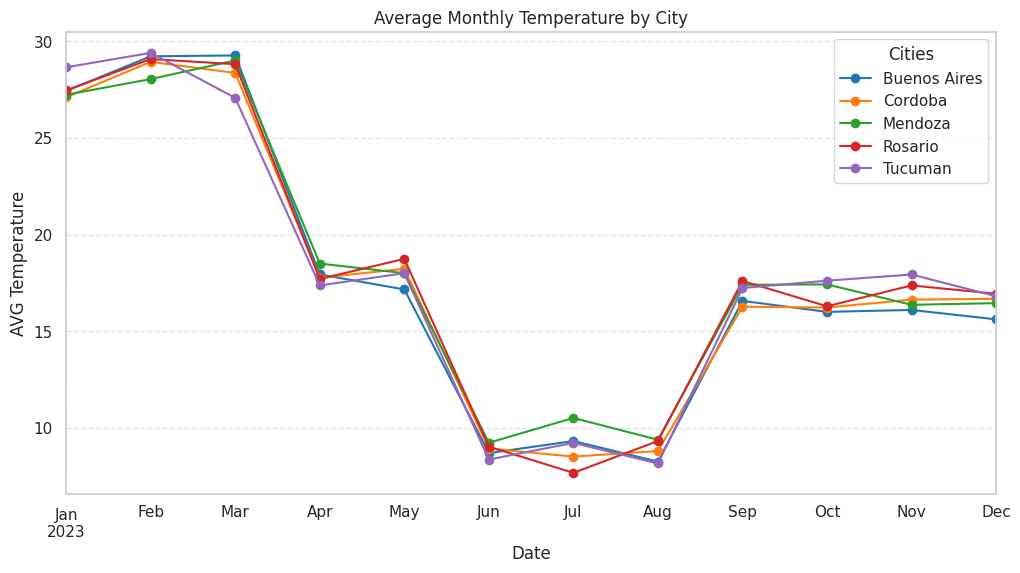

In [13]:
mis_colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
df_cities = df_temp.groupby('City')['Max Temperature'].resample('MS').mean().unstack(level=0)
df_cities.plot(kind='line', figsize=(12, 6), marker='o', color=mis_colores)
plt.title('Average Monthly Temperature by City')
plt.ylabel('AVG Temperature')
plt.legend(title='Cities', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 📌 Comparative Seasonal Trends by City

**Resampled Time Series** plot compares the thermal behavior of all cities in a single view. This identifies which cities react more sharply to seasonal changes and which ones maintain a more stable climate.

**All cities** follow a highly synchronized U-shaped curve, typical of the Southern Hemisphere, with the lowest temperatures centered in **June** and **July**.

**Tucumán** (purple line) and **Rosario** (red line) consistently stay at the top of the graph during the summer months, showing higher thermal intensity.

During the winter, **Buenos Aires** (blue line) and **Mendoza** (green line) compete for the lowest average temperatures, showing a much more pronounced cooling than the northern cities.

Interestingly, around **September/October**, the temperatures of all cities tend to converge before diverging again for the summer heat.

Although all cities follow the same seasonal rhythm, **Tucumán** and **Rosario** act as the **"thermal drivers"** of the group, maintaining higher averages year-round. In contrast, **Mendoza** and **Buenos Aires** exhibit the most significant drops, marking them as the regions with **the most noticeable winters** in this 2023 dataset.

## 📌 Precipitation Analysis

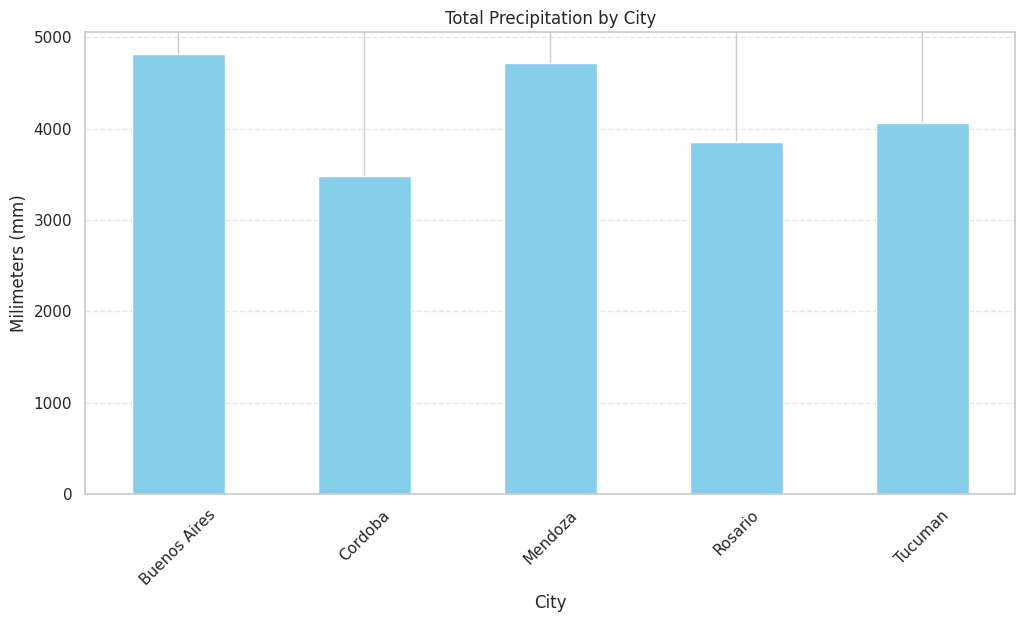

In [14]:
df_total_precipitation = df_temp.groupby('City')['Precipitation'].sum()

plt.figure(figsize=(12, 6))
df_total_precipitation.plot(kind='bar', rot=45, color='skyblue')
plt.title('Total Precipitation by City')
plt.ylabel('Milimeters (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 📌 Annual Cumulative Precipitation Analysis

We calculate the total rainfall (**in millimeters**) for each city throughout 2023. We understand environmental humidity and water availability, which directly influences local temperature regulation and climate stability.

**Buenos Aires** is the clear leader in rainfall for 2023, showing the highest water accumulation among the five cities.

**Mendoza** unexpectedly ranks as the second city with the most precipitation, followed closely by **Rosario**. This is a significant finding as it deviates from the typical arid expectations for the Cuyo region in this specific year.

**Córdoba** shows the lowest cumulative precipitation in the dataset, marking it as the city with the most significant water deficit during 2023.

**Tucumán** sits in a middle-to-low position compared to **Buenos Aires** and Mendoza, showing more moderate accumulation than expected for its latitude.

The 2023 data reveals an atypical precipitation distribution. While **Buenos Aires** remains the wettest city, **Mendoza's** high ranking suggests an unusually rainy year for the region or a data trend that contrasts with its historical aridity. Conversely, **Córdoba's** status as the driest city highlights a year of severe drought or low moisture compared to its peers.



## 📌 Precipitation Analysis by City

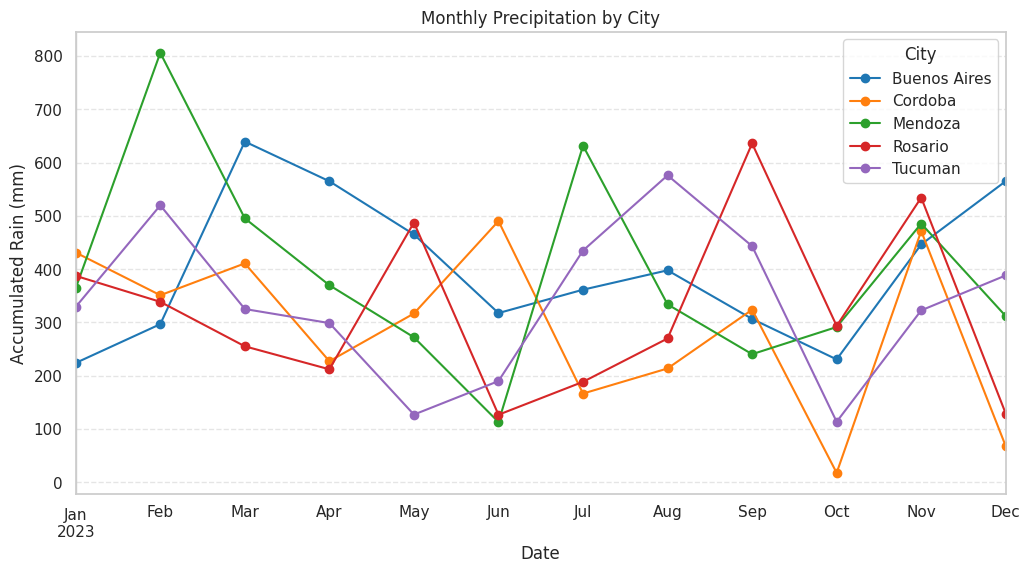

In [15]:
mis_colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
df_monthly_precipitation = df_temp.groupby('City')['Precipitation'].resample('MS').sum().unstack(level=0)

df_monthly_precipitation.plot(kind='line', marker='o', figsize=(12,6), color=mis_colores)
plt.title('Monthly Precipitation by City')
plt.xlabel('Date')
plt.ylabel('Accumulated Rain (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='City')
plt.show()

### 📌 Monthly Precipitation Trends by City

**A resampled Time Series** visualizes how rainfall is distributed throughout the year. We identify if a city's high annual accumulation is due to constant rain or specific extreme weather events.

**Buenos Aires** (blue line) and **Mendoza** (green line) exhibit the most aggressive spikes of the year. **Buenos Aires** experienced its highest discharge in **March**, while **Mendoza** recorded an extreme and unusual event in **December**, which significantly inflates its annual average.

A generalized drought period is observed between June and September for all cities, where all lines converge near zero.

**Córdoba** (orange line) displays the flattest behavior, with no significant recovery peaks. This positions it as the city with the lowest water intake during 2023.

**Rosario** (red line) shows a more distributed but moderate rainfall activity, with a relevant peak toward the end of the first quarter, similar to Buenos Aires but with lower intensity.

The 2023 rainfall regime was **driven by isolated events** rather than seasonal consistency. **Mendoza's** high accumulation is almost exclusively due to an atypical **December**, while **Buenos Aires'** stability was broken by an exceptionally rainy **March**. Conversely, the lack of these "storm peaks" left **Córdoba** in a state of comparative aridity.

## 📌 Precipitation vs Temperature in Buenos Aires city

In [16]:
df_pre_ba = df_temp[df_temp['City'] == 'Buenos Aires']
df_pre_ba = df_pre_ba['Precipitation'].resample('MS').sum()

df_temp_ba = df_temp[df_temp['City'] == 'Buenos Aires']
df_temp_ba = df_temp_ba['Max Temperature'].resample('MS').mean()

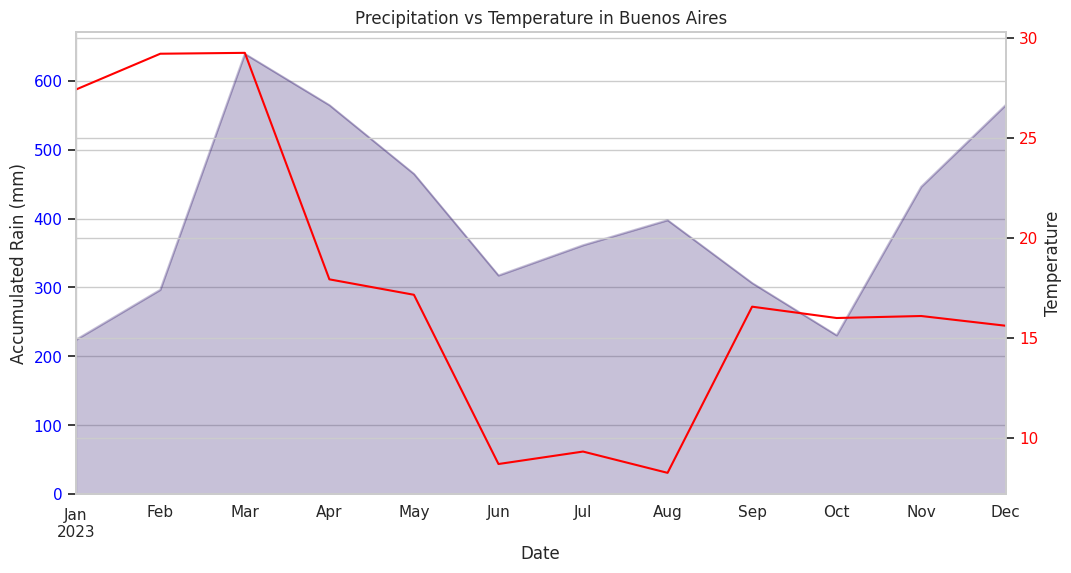

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

df_pre_ba.plot(kind='area', ax= ax1, alpha=0.3)
df_temp_ba.plot(kind='line', ax=ax2, color='red')
ax1.set_ylabel('Accumulated Rain (mm)')
ax2.set_ylabel('Temperature')
ax1.set_xlabel('Date')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Precipitation vs Temperature in Buenos Aires')
plt.show()

### 📌 Precipitation vs. Temperature: Buenos Aires 2023

**Dual-axis visualization** correlates two fundamental climate variables.We identify whether extreme rainfall events are linked to warm seasons (convective rains) or occur independently of thermal patterns.

A strong correlation is observed in the first quarter. March stands out as a critical month where the average maximum temperature remains high **(~29°C)** and precipitation reaches its annual peak, exceeding **600 mm**.

A proportional decrease occurs between **June** and **August**. The drop in temperature below **10°C** acts as a predictor for the decrease in rainfall, which hits its lowest point in **August** **(near 50 mm)**.

Starting in **October**, the temperature curve (red line) begins its seasonal ascent, which triggers a renewed pluvial activity, although without reaching the extreme levels recorded in the **first quarter**.

There was a marked seasonal dependency in **Buenos Aires** during 2023: extreme summer heat acted as the primary engine for massive precipitation. However, the **March** event is a statistical anomaly within the dataset, as it tripled the average rainfall of the surrounding months, suggesting an extraordinary **storm event** rather than a regular climatic pattern.

## 📌 Precipitation vs Temperature in Cordoba, Rosario, Mendoza and Tucuman

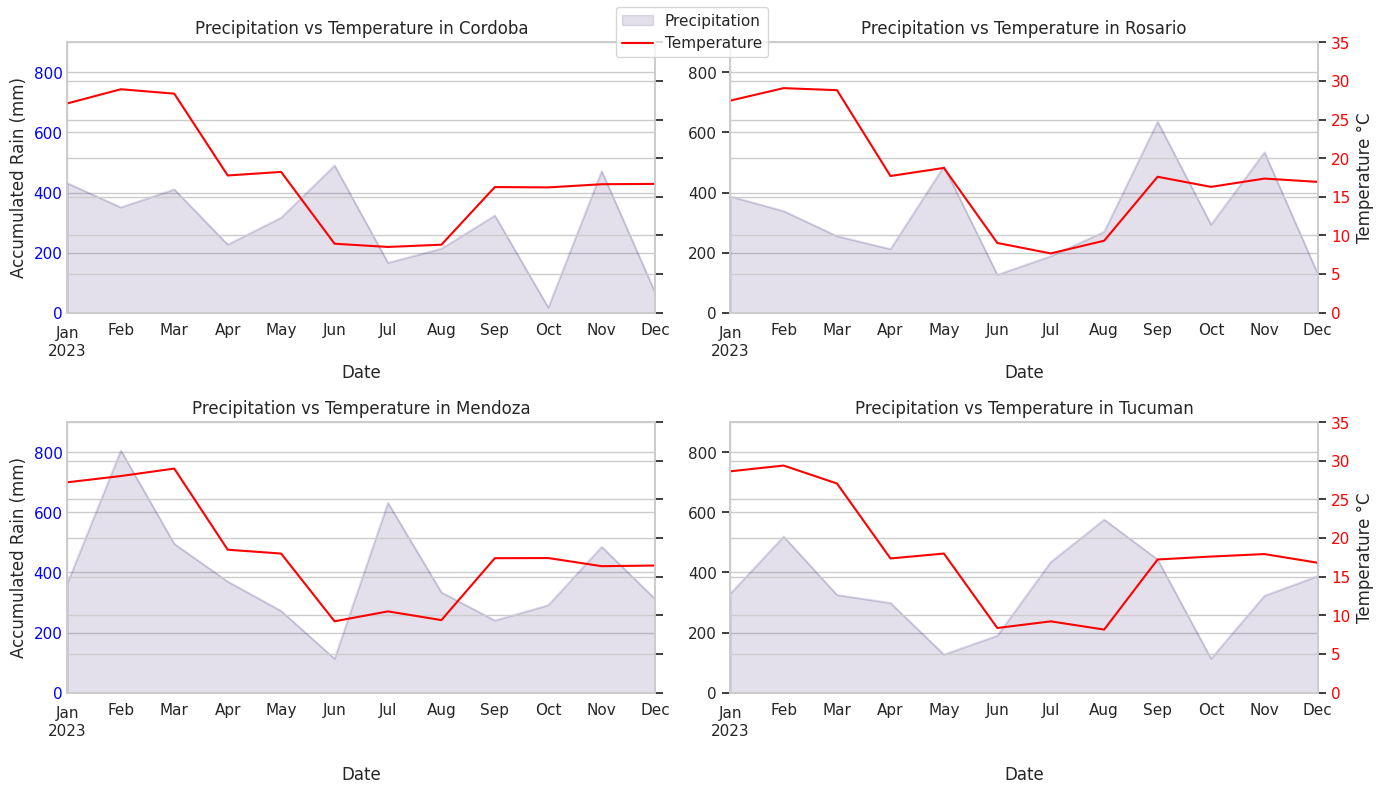

In [18]:
cities = ['Cordoba', 'Rosario', 'Mendoza', 'Tucuman']

fig, axs = plt.subplots(2,2, figsize=(14, 8))

for i, city in enumerate(cities):
    df_pre_temp = df_temp[df_temp['City'] == city]
    sum_pre = df_pre_temp['Precipitation'].resample('MS').sum()
    avg_temp = df_pre_temp['Max Temperature'].resample('MS').mean()
    
    # We calculate row and column to choose the axs where we will ploting.
    row = i // 2
    col = i % 2
    ax_pre = axs[row, col]
    ax_temp = ax_pre.twinx()
    
    area = sum_pre.plot(kind='area', ax=ax_pre, alpha=0.15, zorder=1)
    line = avg_temp.plot(kind='line', ax = ax_temp, color='red', zorder=2)

    if i == 0:
        area_legend = ax_pre.collections[0]
        line_legend = ax_temp.get_lines()[0]
        

    ax_pre.set_title(f'Precipitation vs Temperature in {city}')
    ax_pre.set_ylim(0,900)
    ax_temp.set_ylim(0,35)
    if col == 0:
        ax_pre.set_ylabel('Accumulated Rain (mm)')
        ax_temp.set_yticklabels([])
        ax_pre.tick_params(axis='y', labelcolor = 'blue', length=0)
    else:
        ax_temp.set_ylabel('Temperature °C')
        ax_temp.tick_params(axis='y', labelcolor = 'red')
    if row == 1:
        ax_pre.set_xlabel('Date', labelpad = 20)
fig.legend([area_legend, line_legend], ['Precipitation', 'Temperature'], loc = 'upper center', ncol=1)
plt.tight_layout()
plt.show()

## 📌 Comparative Analysis: Precipitation vs. Temperature (Regional Overview)

A synchronized comparison of climate patterns across four major regions. We objectively identify which cities experience more extreme weather events and how their specific geography influences the correlation between heat and moisture.

**Mendoza** exhibits the most volatile rainfall behavior, with two massive atypical peaks in **February** and **July**, the latter being particularly unusual for a winter month in a semi-arid region.

Unlike precipitation, the temperature curves (red lines) are nearly identical across all four cities, showing a synchronized drop toward the winter solstice **(June/July)** and a steady recovery. This confirms that while the thermal regime is regional, the pluvial regime is highly local.

A notable technical observation is the sharp drop in precipitation in **Cordoba** and **Tucuman** during **October**, which occurs despite rising temperatures. This suggests a temporary atmospheric block or a specific regional dry spell during the 2023 spring season.

Temperature is not a perfect predictor of rainfall across these regions. While theory suggests higher temperatures lead to more rain, the **"July Peak"** in **Mendoza** and the **"October Dry Spell"** in **Cordoba/Tucuman** prove that regional geographic factors and isolated weather fronts had a heavier impact on the 2023 water cycle than the seasonal thermal trend alone.

## 📌 Conclusion

This analysis explored the climatic interplay between temperature and precipitation across key Argentine cities during the 2023-2024 period. The results reveal distinct regional seasonal trends, particularly highlighting the high thermal variance in Mendoza and the maritime influence on Buenos Aires' precipitation cycles.

## 📌 Insights

- Thermal Extremes: **Mendoza** consistently recorded the highest average maximum temperatures among the analyzed cities, reflecting its continental climate and proximity to the Andes.
- Cyclical Seasonality: A robust seasonal pattern is evident across all regions. A sharp decline in temperature occurs between June and September, aligning perfectly with the Southern Hemisphere's winter solstice and transition periods.
- Year-over-Year Variance: Preliminary data suggests a significant downward shift in temperatures for 2024 compared to 2023. This **~10°C** variance in certain months is a significant outlier that warrants a deeper investigation into data collection methods or specific regional atmospheric phenomena.
- **Buenos Aires** Rainfall Dynamics: In **Buenos Aires**, peak precipitation coincided with high-temperature periods (specifically March). This suggests a positive correlation between thermal energy and convective rainfall events during the late summer.
- Geographic Clustering: **Córdoba** and **Rosario** exhibit nearly identical climatic behaviors. Their geographical proximity results in synchronized rainfall spikes during the transition seasons (Autumn and Spring).
- Regional Divergence (**Tucumán** vs. **Mendoza**): A major contrast was identified in summer behavior: while **Mendoza** sees a massive rainfall surge **(~800 mm)** during high-heat months, **Tucumán** maintains a surprisingly dry profile during its warmer periods. This divergence suggests that altitude and pressure systems play a larger role than temperature alone in these provinces.

## 📌 Future Work

Future versions of this project will integrate **humidity** and **wind speed** data to better explain the **Tucumán/Mendoza** divergence.